# Supplementary spatial maps

Explore proposal rankings, narrower self-placement groups, shared participant–proposal PCA, and the three country maps. This notebook produces Figures S3, S6, S7, and S13.

**Inputs:** the included spatial files in `data/processed/figure_inputs/spatial`, regenerated by notebook 09 from the country fits, metadata, and notebook 06 rankings. **Outputs:** PDFs in `outputs/figures`, plotting data in `outputs/tables/supplementary_spatial`, and sample counts and label positions in `outputs/diagnostics`.

**Run or explore:** run top to bottom in a fresh kernel. This notebook is independent of notebook 12 and does not train models or recalculate TrueSkill rankings. The choices that control samples, contour levels, and labels are visible below.

Each country uses a separately estimated space. Compare organization within its own panel. The figures do not measure between-country differences in polarization.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")


## Join coordinates to consistent participant labels

Each person contributes once. Repeated identical left/right labels are collapsed, and IDs with labels on both sides are excluded. Neutral and missing labels do not enter these group displays. Coordinates are unchanged by this filtering.

The proposal ranking is joined by proposal ID, not row order. The ratio of the left rank to the right rank measures relative group preference. Its reciprocal gives the right-side ordering. Sorting these ratios produces the integer labels in Figure S3.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."

assert (
    ROOT / "data/processed/figure_inputs/spatial"
).is_dir(), "Run from the project root or notebooks directory."
DATA = ROOT / "data/processed/figure_inputs/spatial"
OUT = ROOT / "outputs" / "tables" / "supplementary_spatial"
FIG = ROOT / "outputs" / "figures"
DIAG = ROOT / "outputs" / "diagnostics"
for directory in [OUT, FIG, DIAG]:
    directory.mkdir(parents=True, exist_ok=True)
COLORS = {"Left": "#D55E00", "Right": "#0072B2"}
STYLES = {"Left": "-", "Right": "--"}
CONTOUR_MASSES = [0.95, 0.80, 0.50]
DENSITY_FILL_ALPHA = 0.07
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "pdf.fonttype": 42,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.facecolor": "white",
    }
)
COUNTRIES = ["Chile", "France", "Brazil"]
coordinates, proposals, metadata, people, sample_rows = {}, {}, {}, {}, []
binary_conflict_counts = {}
for country in COUNTRIES:
    key = "uuid" if country == "Chile" else "user_id"
    coordinates[country] = pd.read_csv(DATA / f"{country}_coordsU.csv").rename(
        columns={key: "participant_id"}
    )
    proposals[country] = pd.read_csv(DATA / f"{country}_coordsP.csv")
    metadata[country] = pd.read_csv(DATA / f"{country}_metadata.csv").rename(
        columns={key: "participant_id"}
    )
    assert coordinates[country].participant_id.is_unique
    assert proposals[country].option_id.is_unique
    meta = metadata[country].copy()
    meta["side"] = np.where(
        meta.politica.isin(range(5) if country == "Chile" else [1, 2]),
        "Left",
        np.where(
            meta.politica.isin(range(6, 11) if country == "Chile" else [4, 5]), "Right", None
        ),
    )
    linked = coordinates[country].merge(meta, on="participant_id", validate="one_to_many")
    selected = linked[linked.side.notna()].copy()
    unique = selected[["participant_id", "z1", "z2", "side"]].drop_duplicates()
    conflicts = unique.groupby("participant_id").side.nunique().gt(1)
    excluded = conflicts[conflicts].index
    binary_conflict_counts[country] = len(excluded)
    clean = unique[~unique.participant_id.isin(excluded)].copy()
    assert clean.participant_id.is_unique
    people[country] = clean
    sample_rows.append(
        {
            "country": country,
            "analysis": "binary overall",
            "n": len(clean),
            "left": int((clean.side == "Left").sum()),
            "right": int((clean.side == "Right").sum()),
            "conflicting_ids_excluded": len(excluded),
        }
    )


## Join proposal names and rankings

The two rankings are ordered separately because relative support can differ between ideological groups.


In [3]:
labels = pd.read_csv(DATA / "chile_labels.tsv", sep="\t").rename(columns={"id": "option_id"})
proposals["Chile"] = proposals["Chile"].merge(labels, on="option_id", validate="one_to_one")
ranking = pd.read_csv(DATA / "Ranking_propuestas_trueskill_primerciclo.csv").rename(
    columns={"id": "option_id"}
)
assert ranking.option_id.is_unique
ranked = proposals["Chile"].merge(
    ranking[["option_id", "ranking_izquierda_sort", "ranking_derecha_sort"]],
    on="option_id",
    validate="one_to_one",
)
rank_columns = {"Left": "ranking_izquierda_sort", "Right": "ranking_derecha_sort"}
rank_orders = {
    side: ranked.sort_values(column, ascending=True).assign(rank=np.arange(1, len(ranked) + 1))
    for side, column in rank_columns.items()
}
rank_output = pd.concat(
    [frame.assign(side=side) for side, frame in rank_orders.items()], ignore_index=True
)
display(rank_output)
rank_output.to_csv(OUT / "proposal_ranks.csv", index=False)


,option_id,z1,z2,short_name,name,topic_name,ranking_izquierda_sort,ranking_derecha_sort,rank,side
0,23,0.178248,0.605319,Nueva Constitución,Nueva Constitución para Chile,Modernización del Estado,0.013333,75.000000,1,Left
1,37,0.083926,0.793352,Asamblea Constituyente,Asamblea Constituyente,Modernización del Estado,0.056818,17.600000,2,Left
2,6,0.185360,0.471810,Agua,Desprivatización del Agua,Economía,0.065217,15.333333,3,Left
3,85,0.236405,0.428052,Progresividad de Impuestos,Aumentar progresividad de impuestos (más impue...,Política Tributaria,0.133333,7.500000,4,Left
4,57,0.244214,0.862272,Derechos Humanos,Investigación Judicial de Violaciones Reciente...,Política Criminal,0.170732,5.857143,5,Left
...,...,...,...,...,...,...,...,...,...,...
175,57,0.244214,0.862272,Derechos Humanos,Investigación Judicial de Violaciones Reciente...,Política Criminal,0.170732,5.857143,86,Right
176,85,0.236405,0.428052,Progresividad de Impuestos,Aumentar progresividad de impuestos (más impue...,Política Tributaria,0.133333,7.500000,87,Right
177,6,0.185360,0.471810,Agua,Desprivatización del Agua,Economía,0.065217,15.333333,88,Right
178,37,0.083926,0.793352,Asamblea Constituyente,Asamblea Constituyente,Modernización del Estado,0.056818,17.600000,89,Right


## Define the density display and coordinate orientation

A Gaussian KDE with Scott bandwidth is evaluated on a 200 × 200 within-group grid. Sorting grid values from highest to lowest and accumulating their mass gives contour thresholds for fixed proportions of density mass on that finite grid. The small local functions are reused across figures and do not save files.

For display, the horizontal coordinate is `z2` and the vertical coordinate is `z1`. France additionally reflects the vertical coordinate as `1 − z1`. The same swap and reflection are applied to participants and proposals, preserving every Euclidean distance within that map.


Contours enclose 95%, 80%, and 50% of the grid density mass, with a single pale fill inside the outer contour. This display matches notebook 12 and retains the same KDE and outer extent.

In [4]:
# Scott Gaussian KDE uses a 200 x 200 within-group grid.
# Contours use within-group probability proportions.
def density(frame):
    """Return the KDE grid and probability-mass contour heights."""
    xy = frame[["x", "y"]].to_numpy().T
    estimator = gaussian_kde(xy, bw_method="scott")
    x, y = np.mgrid[xy[0].min() : xy[0].max() : 200j, xy[1].min() : xy[1].max() : 200j]
    values = estimator(np.vstack([x.ravel(), y.ravel()])).reshape(x.shape)
    ordered = np.sort(values.ravel())[::-1]
    cumulative = np.cumsum(ordered) / ordered.sum()
    levels = np.unique(
        [
            ordered[min(np.searchsorted(cumulative, p), len(ordered) - 1)]
            for p in CONTOUR_MASSES
        ]
    )
    return x, y, values, levels


def draw_density(ax, result, side, filled=True):
    """Draw a previously fitted density without changing its estimator."""
    x, y, values, levels = result
    if filled:
        ax.contourf(
            x,
            y,
            values,
            levels=[levels[0], values.max() * (1 + 1e-8)],
            colors=[COLORS[side]],
            alpha=DENSITY_FILL_ALPHA,
        )
    ax.contour(
        x,
        y,
        values,
        levels=levels,
        colors=[COLORS[side]],
        linestyles=STYLES[side],
        linewidths=np.linspace(0.55, 1.1, len(levels)),
        alpha=0.85,
    )


def orient(frame, country):
    """Apply the same distance-preserving display transform to every entity."""
    result = frame.copy()
    result["x"] = result.z2
    result["y"] = 1 - result.z1 if country == "France" else result.z1
    return result


plot_people = {country: orient(people[country], country) for country in COUNTRIES}
plot_proposals = {country: orient(proposals[country], country) for country in COUNTRIES}
densities = {
    country: {side: density(frame[frame.side == side]) for side in ["Left", "Right"]}
    for country, frame in plot_people.items()
}


def decorate(ax, title):
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Coordinate 1", ylabel="Coordinate 2", title=title)
    ax.set_aspect("equal", adjustable="box")


def legend(ax, proposal=True):
    handles = [
        Line2D([0], [0], color=COLORS[s], ls=STYLES[s], label=s) for s in ["Left", "Right"]
    ]
    if proposal:
        handles.append(
            Line2D(
                [0], [0], color="#666666", marker="o", ls="", markersize=4, label="Proposals"
            )
        )
    ax.legend(handles=handles, frameon=False, fontsize=8, loc="upper left")


## Figure S3: proposals ordered by relative group preference

Panels show the top 5, 10, and 15 proposals by relative group preference for each side. The printed number is the position after sorting the left/right rank ratio for the left and its reciprocal for the right. These positions differ from the original within-group TrueSkill ranks.

The label-placement loop searches nearby offsets from shortest to longest. It checks the rendered text boxes, including two-digit ranks, and accepts the first position inside the axes that does not overlap earlier labels. Only text moves. Proposal points retain their fitted coordinates and are connected to their labels by thin lines.


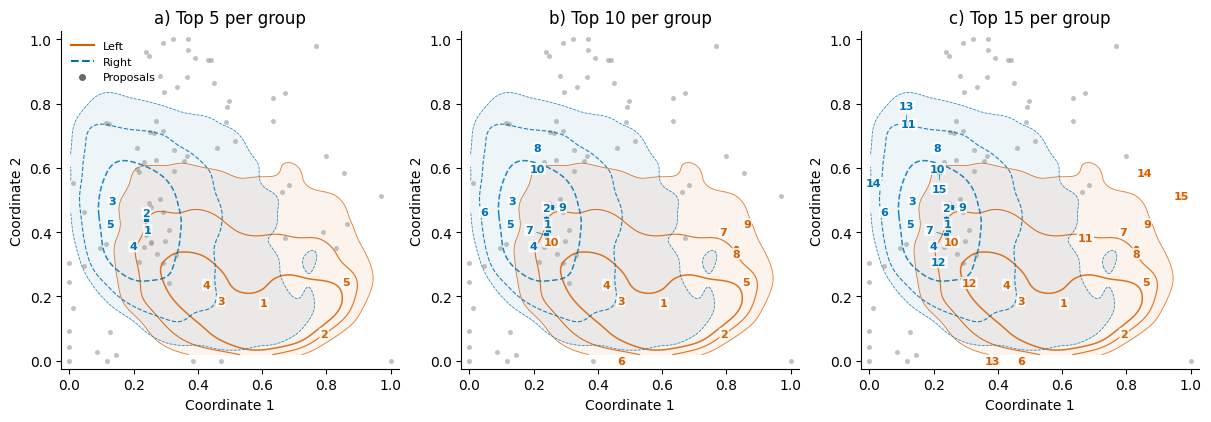

,top_per_group,side,option_id,rank,proposal_x,proposal_y,label_x,label_y
0,5,Left,23,1,0.605319,1.782478e-01,0.605319,1.782478e-01
1,5,Left,37,2,0.793352,8.392607e-02,0.793352,8.392607e-02
2,5,Left,6,3,0.471810,1.853596e-01,0.471810,1.853595e-01
3,5,Left,85,4,0.428052,2.364054e-01,0.428052,2.364054e-01
4,5,Left,57,5,0.862272,2.442137e-01,0.862272,2.442137e-01
5,5,Right,45,1,0.243394,4.067104e-01,0.243394,4.067104e-01
6,5,Right,64,2,0.240107,4.419055e-01,0.240107,4.591953e-01
7,5,Right,8,3,0.134709,4.979890e-01,0.134709,4.979890e-01
8,5,Right,21,4,0.199321,3.556593e-01,0.199321,3.556593e-01
9,5,Right,78,5,0.126733,4.251936e-01,0.126733,4.251936e-01


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout="constrained")
labels_by_panel = []
for panel, (count, ax) in enumerate(zip([5, 10, 15], axes)):
    for side in ["Left", "Right"]:
        draw_density(ax, densities["Chile"][side], side)
    p = plot_proposals["Chile"]
    ax.scatter(p.x, p.y, s=13, c="#999999", alpha=0.6, linewidths=0)
    annotations = []
    for side in ["Left", "Right"]:
        chosen = orient(rank_orders[side].head(count), "Chile")
        ax.scatter(
            chosen.x,
            chosen.y,
            s=20,
            c=COLORS[side],
            marker="o" if side == "Left" else "s",
            edgecolors="white",
            linewidths=0.5,
            zorder=6,
        )
        for row in chosen.itertuples():
            annotation = ax.annotate(
                str(row.rank),
                xy=(row.x, row.y),
                xytext=(row.x, row.y),
                ha="center",
                va="center",
                fontsize=8,
                color=COLORS[side],
                fontweight="bold",
                zorder=7,
                bbox={"boxstyle": "round,pad=.08", "fc": "white", "ec": "none", "alpha": 0.85},
                arrowprops={"arrowstyle": "-", "color": COLORS[side], "lw": 0.5},
            )
            annotations.append((annotation, row, side))
    decorate(ax, f"{chr(97+panel)}) Top {count} per group")
    ax.set(
        xlim=(-0.025, 1.025),
        ylim=(-0.025, 1.025),
        xticks=np.arange(0, 1.01, 0.2),
        yticks=np.arange(0, 1.01, 0.2),
    )
    labels_by_panel.append((count, ax, annotations))
legend(axes[0])

# Finalize axes before measuring labels. Move text only, never proposal points.
# Actual rendered bounding boxes account for wider two-digit ranks.
fig.canvas.draw()
fig.set_layout_engine("none")
renderer = fig.canvas.get_renderer()
offsets = sorted(
    [(dx, dy) for dx in range(-48, 49, 4) for dy in range(-48, 49, 4)],
    key=lambda offset: offset[0] ** 2 + offset[1] ** 2,
)
label_positions = []
for count, ax, annotations in labels_by_panel:
    occupied = []
    for annotation, row, side in annotations:
        anchor = ax.transData.transform((row.x, row.y))
        for dx, dy in offsets:
            position = ax.transData.inverted().transform(
                anchor + np.array([dx, dy]) * fig.dpi / 72
            )
            annotation.set_position(position)
            annotation.update_positions(renderer)
            annotation.update_bbox_position_size(renderer)
            box = annotation.get_bbox_patch().get_window_extent(renderer).padded(2)
            inside = (
                box.x0 >= ax.bbox.x0
                and box.x1 <= ax.bbox.x1
                and box.y0 >= ax.bbox.y0
                and box.y1 <= ax.bbox.y1
            )
            if inside and not any(box.overlaps(previous) for previous in occupied):
                occupied.append(box.frozen())
                label_positions.append(
                    {
                        "top_per_group": count,
                        "side": side,
                        "option_id": row.option_id,
                        "rank": row.rank,
                        "proposal_x": row.x,
                        "proposal_y": row.y,
                        "label_x": float(position[0]),
                        "label_y": float(position[1]),
                    }
                )
                break
        else:
            raise RuntimeError(f"No non-overlapping label position for {side} rank {row.rank}.")
    assert all(not a.overlaps(b) for i, a in enumerate(occupied) for b in occupied[i + 1 :])

display(fig)
fig.savefig(FIG / "FigS3.pdf", bbox_inches="tight")
plt.close(fig)
label_positions = pd.DataFrame(label_positions)
display(label_positions)
label_positions.to_csv(DIAG / "FigS3_label_positions.csv", index=False)


## Figure S6: narrower self-placement bands

The first panel uses the binary sample constructed above. The two narrower panels require a consistent valid left-or-right score before selecting 0–2 versus 8–10, or 0–1 versus 9–10. A person who reported both 0 and 2 can therefore be eligible for the broad binary comparison but excluded from exact-score comparisons. This avoids choosing an arbitrary score.

Scatter points show participants. Contours summarize each group's density. Only the dense scatter layer is rasterized inside the PDF to keep the file manageable. Text and contours remain vector graphics.


,participant_id,z1,z2,side,x,y,panel,politica
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677,Right,0.677677,0.620236,1,NaN
1,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773,Right,0.733773,0.143278,1,NaN
2,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808,Left,0.412808,0.287662,1,NaN
3,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308,Left,0.210308,0.262506,1,NaN
4,00097f0b-7b32-4962-9780-1ca10ece1571,0.369477,0.271307,Right,0.271307,0.369477,1,NaN
...,...,...,...,...,...,...,...,...
35404,ffbc8b78-8a22-4cec-988e-2ff5714d97b4,0.551979,0.346254,Right,0.346254,0.551979,3,9.0
35405,ffca1f8e-6e37-4efb-baaf-37c41988eba5,0.336313,0.885336,Left,0.885336,0.336313,3,1.0
35406,ffcd572c-70c0-44a4-9505-91ad2ced3c1e,0.372391,0.734884,Left,0.734884,0.372391,3,0.0
35407,ffd73a20-74ce-4cc1-90a9-79737cc94579,0.769533,0.063740,Right,0.063740,0.769533,3,10.0


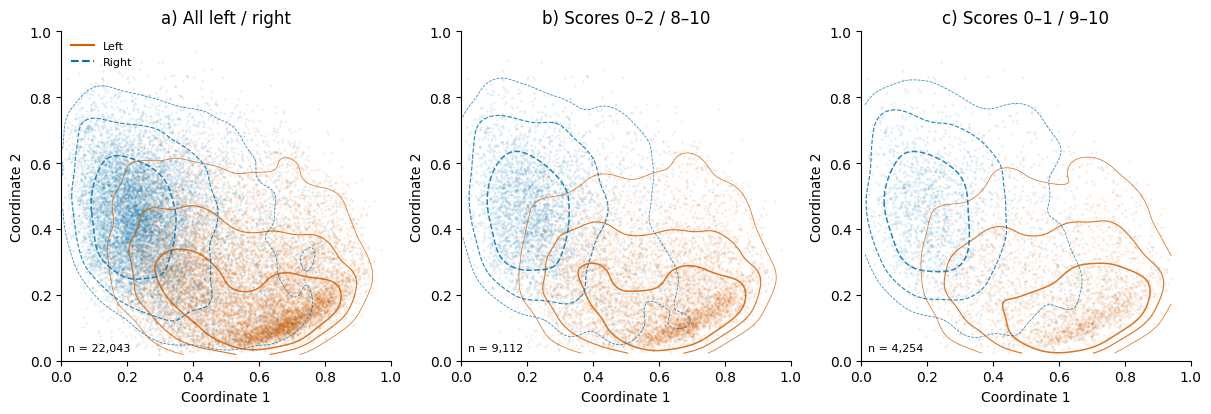

In [6]:
# Compare broad, narrower, and extreme self-placement bands:
# (0--4,6--10), (0--2,8--10), and (0--1,9--10).
# For narrower score bands, exclude IDs with any conflicting valid binary score
# before forming bands. The first panel retains the overall binary-only sample.
meta = metadata["Chile"]
scored = coordinates["Chile"].merge(meta, on="participant_id", validate="one_to_many")
scored = scored[scored.politica.isin(list(range(5)) + list(range(6, 11)))].copy()
scored = scored[["participant_id", "z1", "z2", "politica"]].drop_duplicates()
conflicts = scored.groupby("participant_id").politica.nunique().gt(1)
conflicting_score_ids = conflicts[conflicts].index
scored = scored[~scored.participant_id.isin(conflicting_score_ids)].copy()
assert scored.participant_id.is_unique
score_bands = [
    ("All left / right", range(5), range(6, 11)),
    ("Scores 0–2 / 8–10", range(3), range(8, 11)),
    ("Scores 0–1 / 9–10", range(2), range(9, 11)),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout="constrained")
score_frames = []
for panel, ((title, left_codes, right_codes), ax) in enumerate(zip(score_bands, axes)):
    if panel == 0:
        frame = people["Chile"].copy()
    else:
        frame = scored[scored.politica.isin(list(left_codes) + list(right_codes))].copy()
        frame["side"] = np.where(frame.politica.isin(left_codes), "Left", "Right")
    frame = orient(frame, "Chile")
    assert frame.participant_id.is_unique
    score_frames.append(frame.assign(panel=panel + 1))
    for side in ["Left", "Right"]:
        group = frame[frame.side == side]
        ax.scatter(
            group.x, group.y, s=3, c=COLORS[side], alpha=0.12, linewidths=0, rasterized=True
        )
        draw_density(ax, density(group), side, filled=False)
    decorate(ax, f"{chr(97+panel)}) {title}")
    ax.text(0.02, 0.03, f"n = {len(frame):,}", transform=ax.transAxes, fontsize=8)
    sample_rows.append(
        {
            "country": "Chile",
            "analysis": title,
            "n": len(frame),
            "left": int((frame.side == "Left").sum()),
            "right": int((frame.side == "Right").sum()),
            "conflicting_ids_excluded": (
                binary_conflict_counts["Chile"] if panel == 0 else len(conflicting_score_ids)
            ),
        }
    )
legend(axes[0], proposal=False)
score_data = pd.concat(score_frames, ignore_index=True)
display(score_data)
score_data.to_csv(OUT / "score_band_participants.csv", index=False)
display(fig)
fig.savefig(FIG / "FigS6.pdf", bbox_inches="tight")
plt.close(fig)


## Figure S7: one PCA projection for people and proposals

PCA is fitted once to all Chilean participant coordinates. Its centering vector and loading are then reused to transform proposal coordinates. Fitting a separate PCA to proposals would give a different axis and would destroy this shared interpretation.

The sign is oriented left-to-right after fitting. Both participants and proposals receive the same reflection. Histogram weights use the whole binary sample, so the groups retain their observed relative sizes.


,participant_id,z1,z2,side,PC1
0,000057c7-295c-4a61-8f62-76aff62bf079,0.620236,0.677677,Right,-0.052192
1,00032199-2183-48c0-8f0d-ac37dc8ece60,0.143278,0.733773,Right,-0.360209
2,000629ba-44c0-47c1-b2b2-abe4f0ee808f,0.287662,0.412808,Left,-0.012564
3,0006b923-77a6-40c1-95e0-f98b817bcab2,0.262506,0.210308,Left,0.143137
4,00097f0b-7b32-4962-9780-1ca10ece1571,0.369477,0.271307,Right,0.150640
...,...,...,...,...,...
22038,ffdd7eff-a598-4406-b445-ee1d7b61b039,0.520886,0.368498,Right,0.152177
22039,fff04ade-6ae3-4a80-99ff-446a8bec535d,0.359187,0.410472,Right,0.028540
22040,fff8a6be-746b-4d24-9148-73c8c6accb69,0.218051,0.444988,Left,-0.077598
22041,fffcdf0e-0c78-40f7-915a-d41d6650c99b,0.278650,0.946591,Left,-0.464217


,option_id,z1,z2,short_name,name,topic_name,PC1
0,1,0.663117,0.460457,Farmacias,Creación de Farmacias Populares,Salud,0.153070
1,2,0.977909,0.769293,Marihuana,Legalización de la Marihuana,Salud,0.066913
2,3,0.331054,0.274275,Cárcel Cohecho,Cárcel Efectiva para Soborno y Cohecho,Política Criminal,0.127124
3,4,0.545465,0.685188,Retiro AFP,Retiro Anticipado Fondo de Pensiones,Pensiones,-0.099405
4,5,0.739270,0.115391,Más Metro,Crear Nuevas Líneas de Metro,Vivienda y Transporte,0.483537
...,...,...,...,...,...,...,...
85,86,0.381413,0.672768,CAE,Condonación de las deudas del Crédito con Aval...,Educación,-0.178808
86,87,0.370188,0.254616,Sueldo Mínimo,Aumentar el Sueldo Mínimo,Laboral,0.164998
87,88,0.350024,0.830478,Plebiscitos Nacionales,Habilitar plebiscitos nacionales.,Democracia,-0.327975
88,89,0.293969,0.046756,Autonomía Regional,Entregar más autonomía a las regiones en su go...,Modernización del Estado,0.297234


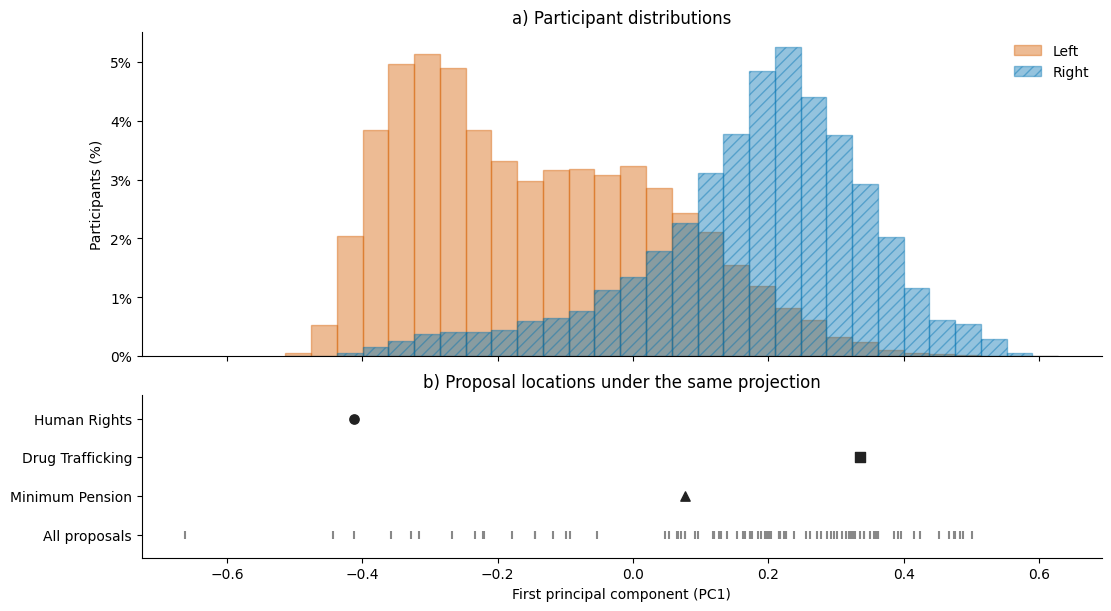

In [7]:
pca = PCA(n_components=1, svd_solver="full")
all_pc = pca.fit_transform(coordinates["Chile"][["z2", "z1"]]).ravel()
projected = coordinates["Chile"][["participant_id"]].assign(PC1=all_pc)
participant_pc = people["Chile"].merge(projected, on="participant_id", validate="one_to_one")
sign = (
    1
    if participant_pc.loc[participant_pc.side == "Left", "PC1"].median()
    < participant_pc.loc[participant_pc.side == "Right", "PC1"].median()
    else -1
)
participant_pc.PC1 *= sign
proposal_pc = proposals["Chile"].copy()
proposal_pc["PC1"] = pca.transform(proposal_pc[["z2", "z1"]]).ravel() * sign
fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 6.0),
    sharex=True,
    layout="constrained",
    gridspec_kw={"height_ratios": [2, 1]},
)
bins = np.histogram_bin_edges(participant_pc.PC1, bins=30)
for side in ["Left", "Right"]:
    vals = participant_pc.loc[participant_pc.side == side, "PC1"]
    axes[0].hist(
        vals,
        bins=bins,
        weights=np.ones(len(vals)) / len(participant_pc),
        color=COLORS[side],
        alpha=0.42,
        edgecolor=COLORS[side],
        hatch=None if side == "Left" else "///",
        label=side,
    )
axes[0].yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
axes[0].set_ylabel("Participants (%)")
axes[0].legend(frameon=False)
axes[0].set_title("a) Participant distributions")
axes[1].scatter(
    proposal_pc.PC1,
    np.zeros(len(proposal_pc)),
    s=26,
    c="#888888",
    marker="|",
    label="All proposals",
)
selected = [
    ("Pensión Mínima", "Minimum Pension"),
    ("Narcotráfico", "Drug Trafficking"),
    ("Derechos Humanos", "Human Rights"),
]
for i, (native, english) in enumerate(selected, start=1):
    point = proposal_pc.loc[proposal_pc.short_name == native, "PC1"]
    assert len(point) == 1
    axes[1].scatter(point, [i], s=45, color="#222222", marker=["^", "s", "o"][i - 1])
axes[1].set_yticks(range(4), ["All proposals"] + [x[1] for x in selected])
axes[1].set_ylim(-0.6, 3.6)
axes[1].set_xlabel("First principal component (PC1)")
axes[1].set_title("b) Proposal locations under the same projection")
display(participant_pc)
participant_pc.to_csv(OUT / "pca_participants.csv", index=False)
display(proposal_pc)
proposal_pc.to_csv(OUT / "pca_proposals.csv", index=False)
display(fig)
fig.savefig(FIG / "FigS7.pdf", bbox_inches="tight")
plt.close(fig)


## Figure S13: country maps with all proposals

Each participant contributes once to their group's density. Gray points locate all proposals in that country's fitted map. The countries have separate learned coordinate systems. Their matching display ranges are a plotting convention, not a shared substantive scale.


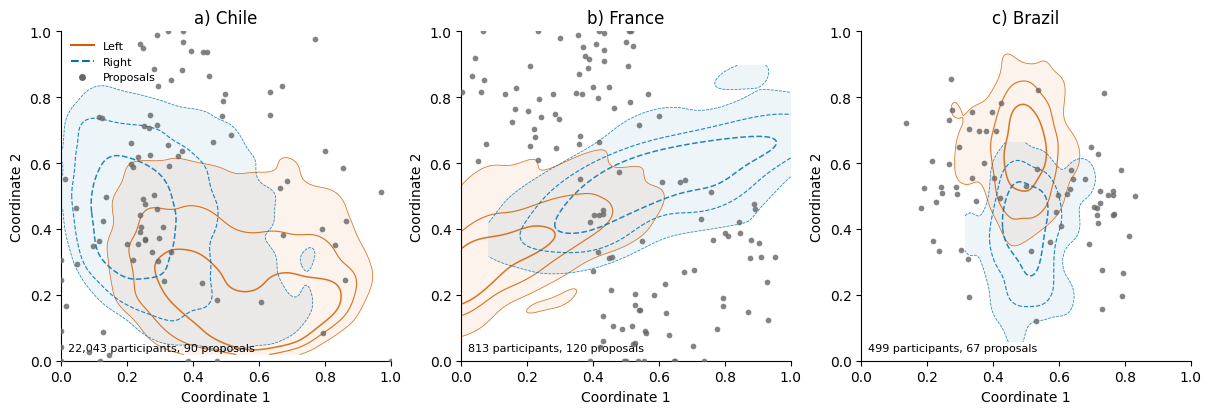

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout="constrained")
for panel, (country, ax) in enumerate(zip(COUNTRIES, axes)):
    for side in ["Left", "Right"]:
        draw_density(ax, densities[country][side], side)
    p = plot_proposals[country]
    ax.scatter(p.x, p.y, s=17, c="#666666", alpha=0.8, linewidths=0, zorder=5)
    decorate(ax, f"{chr(97+panel)}) {country}")
    ax.text(
        0.02,
        0.03,
        f"{len(people[country]):,} participants, {len(p)} proposals",
        transform=ax.transAxes,
        fontsize=8,
    )
legend(axes[0])
display(fig)
fig.savefig(FIG / "FigS13.pdf", bbox_inches="tight")
plt.close(fig)


## Participant counts

Inspect the sample size, group sizes, and conflicting-response exclusions for each displayed comparison.


In [9]:
samples = pd.DataFrame(sample_rows)
display(samples)
samples.to_csv(DIAG / "supplementary_spatial_sample_counts.csv", index=False)


,country,analysis,n,left,right,conflicting_ids_excluded
0,Chile,binary overall,22043,12473,9570,28
1,France,binary overall,813,668,145,0
2,Brazil,binary overall,499,377,122,0
3,Chile,All left / right,22043,12473,9570,28
4,Chile,Scores 0–2 / 8–10,9112,5903,3209,267
5,Chile,Scores 0–1 / 9–10,4254,2688,1566,267
